# Study the SNR in function of the VGA gain

The goal is to observe the evolution of the finger plots in function of the VGA gain


In [1]:
%load_ext autoreload

%autoreload 2

from BaselineAnalysis import *

In [2]:
input_json = '/terabig/nsallin/data/test_baseline/20250701_VGAtest_baselineRuns.json'
output_path = '/terabig/nsallin/data/test_baseline/test_plots'

files = BaselineFiles(input_json=input_json, output_path=output_path, log_level='DEBUG')

2025-07-24 00:20:32,501 - INFO - set_log_level - Log level changed to DEBUG
2025-07-24 00:20:32,503 - INFO - __init__ - The input json file: /terabig/nsallin/data/test_baseline/20250701_VGAtest_baselineRuns.json, 13 data files were found
2025-07-24 00:20:32,503 - INFO - __init__ - The ouput folder: /terabig/nsallin/data/test_baseline/test_plots


In [3]:
files.get_baselines(mode='event', Nevent=5000)


2025-07-24 00:20:32,525 - DEBUG - __init__ - Processing /storage/data/LRS/test_VGA/light_flow_scanner/20250630_VGA_test/baselines/mpd_20250701_174102.flow.hdf5
2025-07-24 00:20:32,526 - DEBUG - __init__ - The ouput folder: /terabig/nsallin/data/test_baseline/test_plots


2025-07-24 00:20:34,812 - DEBUG - __init__ - Number of events in the selection: 66808
2025-07-24 00:20:34,813 - DEBUG - __init__ - Shape of the waveforms array: (66808, 1, 64, 600)
2025-07-24 00:20:34,815 - DEBUG - compute_baselines - Computing the mean baselines of the file /storage/data/LRS/test_VGA/light_flow_scanner/20250630_VGA_test/baselines/mpd_20250701_174102.flow.hdf5 with 5000 events
2025-07-24 00:20:35,952 - DEBUG - compute_baselines - Shape of baselines_event: (5000, 1, 64)
2025-07-24 00:20:35,954 - DEBUG - get_baselines - shape of bl_wvfms.baselines (1, 64), shape of bl_wvfms.baselines_event (5000, 1, 64)
2025-07-24 00:20:35,961 - DEBUG - get_baselines - date: 2025-07-01, alt. name: 24
2025-07-24 00:20:35,975 - DEBUG - __init__ - Processing /storage/data/LRS/test_VGA/light_flow_scanner/20250630_VGA_test/baselines/mpd_20250701_174644.flow.hdf5
2025-07-24 00:20:35,976 - DEBUG - __init__ - The ouput folder: /terabig/nsallin/data/test_baseline/test_plots
2025-07-24 00:20:41,75

## Finger Plots

In [4]:
%load_ext autoreload

%autoreload 2

from GainAnalysis import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:

input_LEDFolder = '/storage/data/LRS/test_VGA/light_flow_scanner/20250630_VGA_test/LED/'
input_LEDFile = 'mpd_20250701_174357.flow.hdf5'

In [6]:
calibClass = calibClass(filedir=input_LEDFolder, filename=input_LEDFile, output_path=None, log_level='DEBUG')

2025-07-24 00:20:58,140 - INFO - set_log_level - Log level changed to DEBUG
2025-07-24 00:20:58,141 - DEBUG - __init__ - Processing /storage/data/LRS/test_VGA/light_flow_scanner/20250630_VGA_test/LED/mpd_20250701_174357.flow.hdf5
2025-07-24 00:20:58,142 - DEBUG - __init__ - The ouput folder: /terabig/nsallin/FSD_calib/evD_mpd_20250701_174357.flow.hdf5/


2025-07-24 00:20:58,589 - DEBUG - __init__ - Number of events in the selection: 11317
2025-07-24 00:20:58,589 - DEBUG - __init__ - Shape of the waveforms array: (11317, 1, 64, 600)


### Waveforms examples - Integral

[112 125]
[112 123]
[112]
[112 128]
[112 125]
[112]


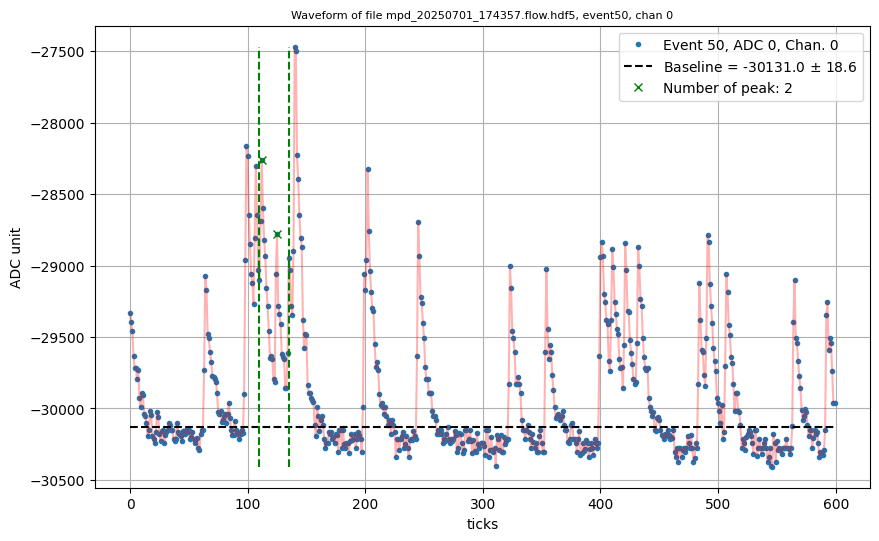

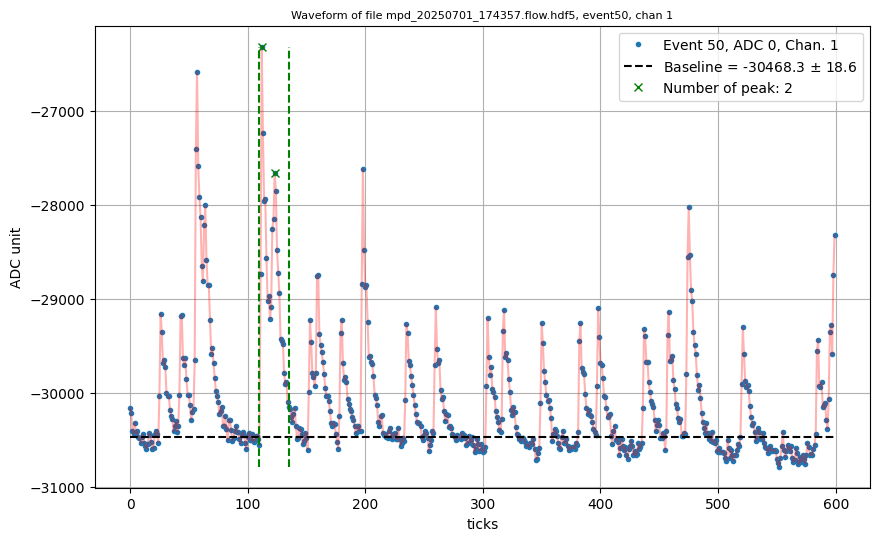

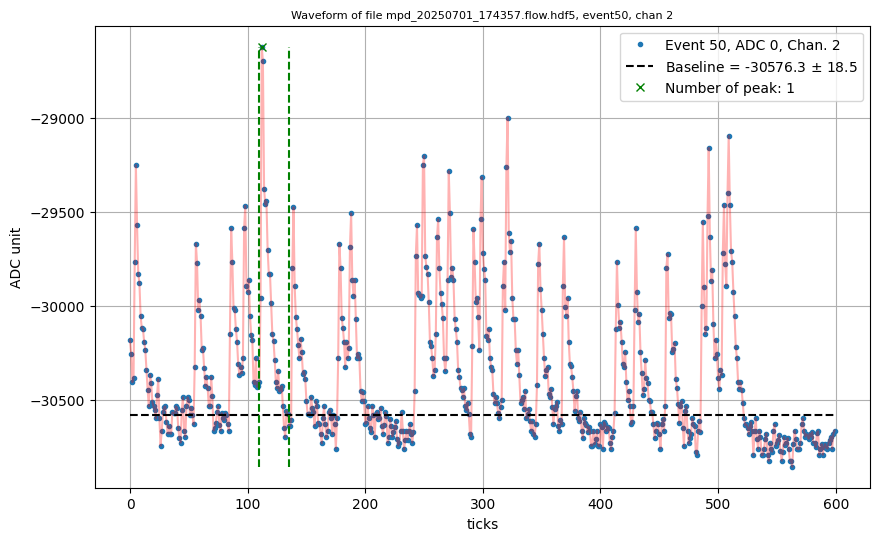

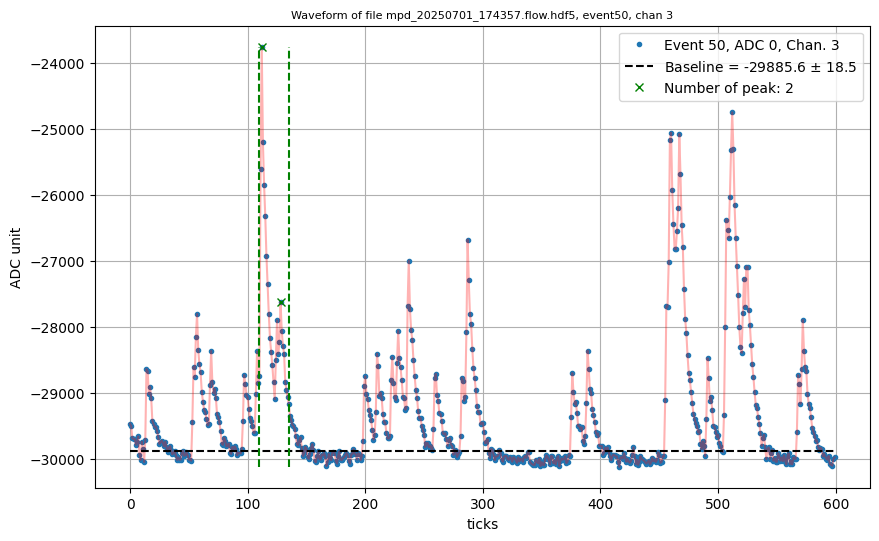

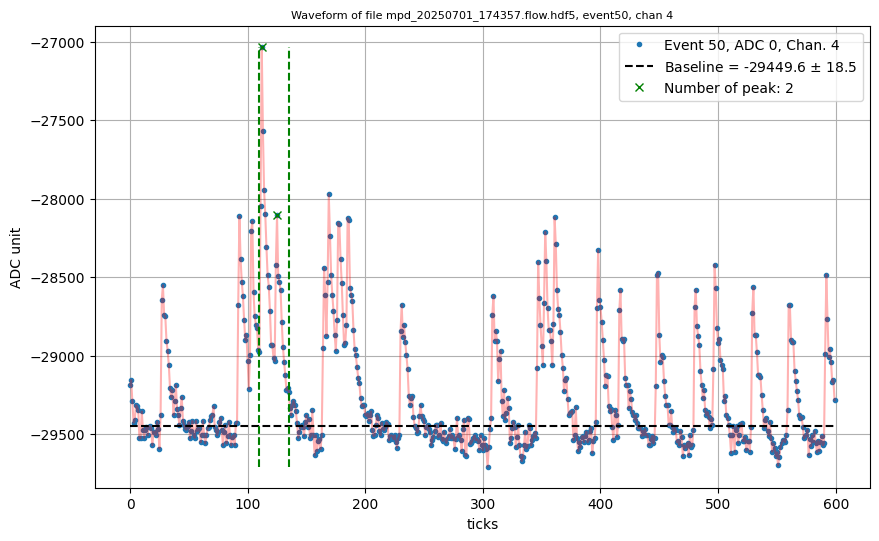

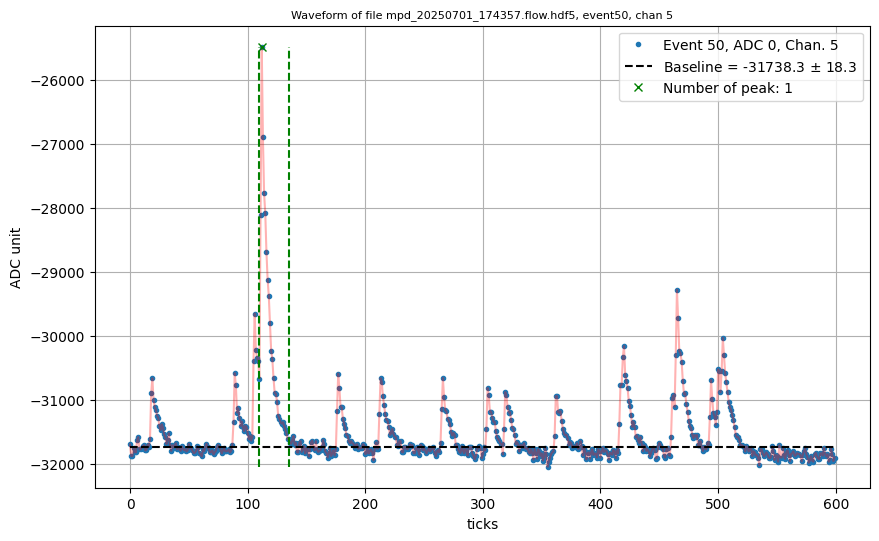

In [7]:
m_event = 50
i_adc = 0
k_chan = 0
j_file = 0

signal_window = [110, 135]

for k_chan in range(6):

    wvfm = calibClass.light_wvfms[m_event, i_adc, k_chan]
    baseline = files.baselines[j_file, i_adc, k_chan]
    baseline_std = files.baselines_std[j_file ,i_adc, k_chan]

    calibClass.findPeak_wvfms(m_event, i_adc, k_chan, minWidth=9, search_int=signal_window)
    peaks_idx = calibClass.peaks_idx[m_event][i_adc][k_chan]
    print(peaks_idx)

    fig = plt.figure(figsize=[10, 6])
    ax = fig.subplots()

    # Compute the x-axis coordinate
    x_ticks = np.arange(0, wvfm.shape[-1],  1)

    xlim = [x_ticks[0], x_ticks[-1]]
    ylim = [np.min(wvfm), np.max(wvfm)]

    ax.set_xlabel('ticks')
    ax.set_ylabel('ADC unit')
    ax.grid(True)

    ax.plot(x_ticks, wvfm, label=f'Event {m_event}, ADC {i_adc}, Chan. {k_chan}', marker='.', ls='')
    ax.plot(x_ticks, wvfm, marker='', ls='-', c='r', alpha=0.3)

    ax.hlines(baseline, xlim[0], xlim[1], color='k', ls='--', label=rf'Baseline = {baseline:.1f} $\pm$ {baseline_std:.1f}')
    ax.vlines(signal_window[0], ylim[0], ylim[1], color='g', ls='--')
    ax.vlines(signal_window[1], ylim[0], ylim[1], color='g', ls='--')

    ax.plot(peaks_idx, wvfm[peaks_idx], color='g', marker='x', ls='', label=f'Number of peak: {len(peaks_idx)}')

    ax.set_title(f'Waveform of file {input_LEDFile}, event{m_event}, chan {k_chan}', fontsize=8)
    ax.legend()

    fig.show()


### Waveforms examples - Amplitude DC


[202 245 323 354 401 410 421 432 484 491 507]
[235 260 304 318 350 383 398 437 458 475 521]
[244 250 262 271 292 299 321 348 369 414 430 457 492 509]
[210 223 228 237 260 287 376 389 460 467 491 512 524 525]
[231 309 347 353 361 398 417 449 481 497 530]
[213 266 304 319 362 363 420 465 494 504]


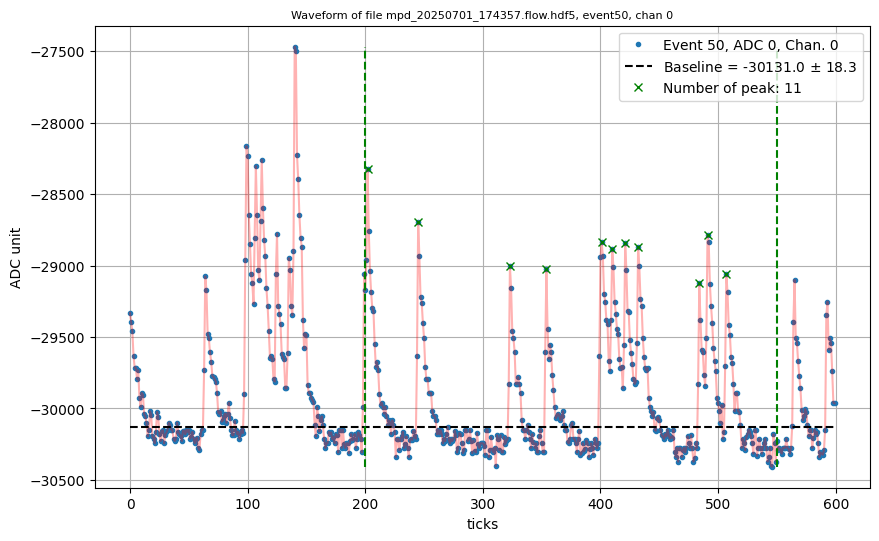

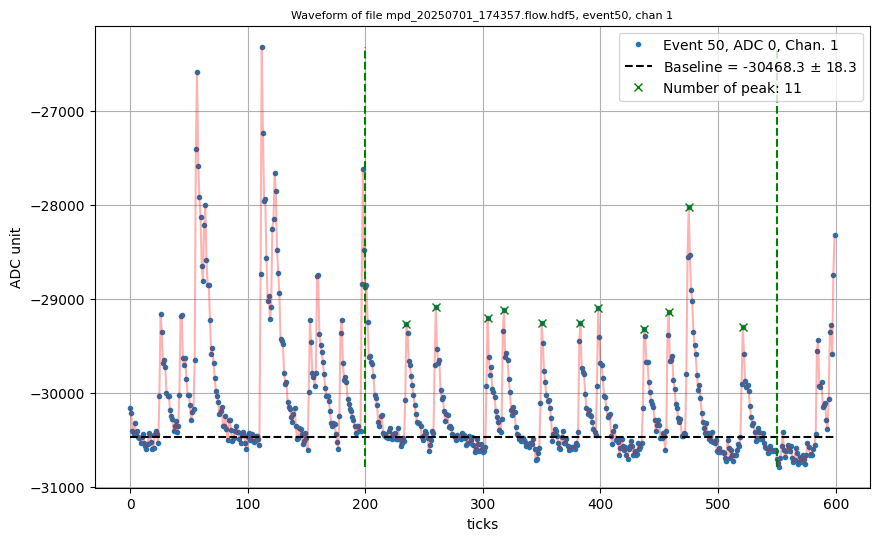

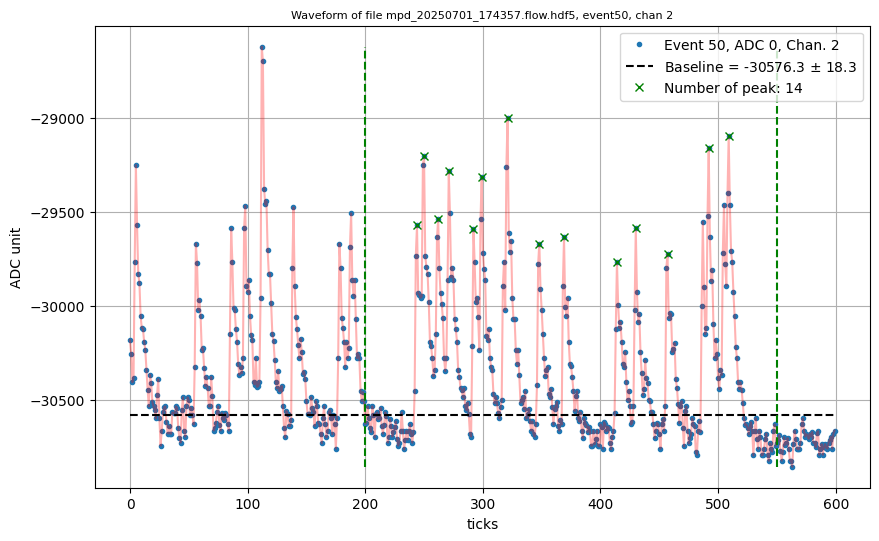

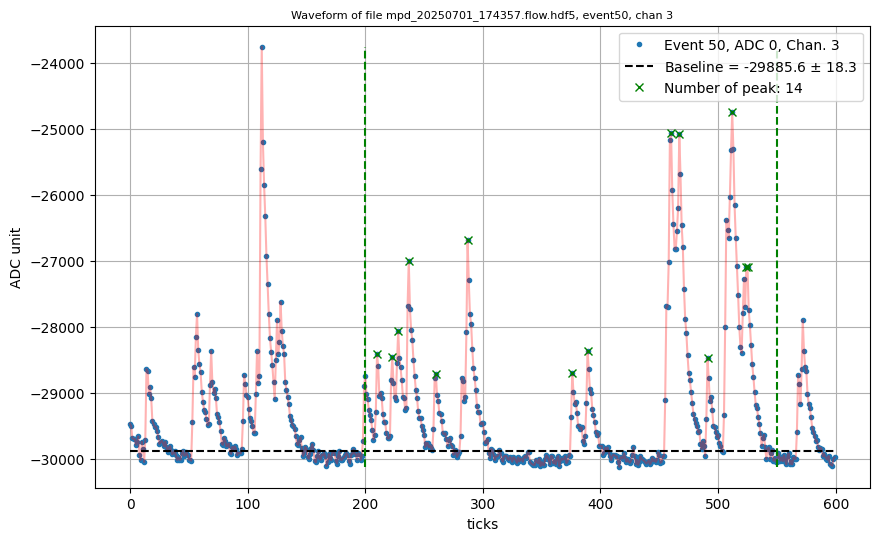

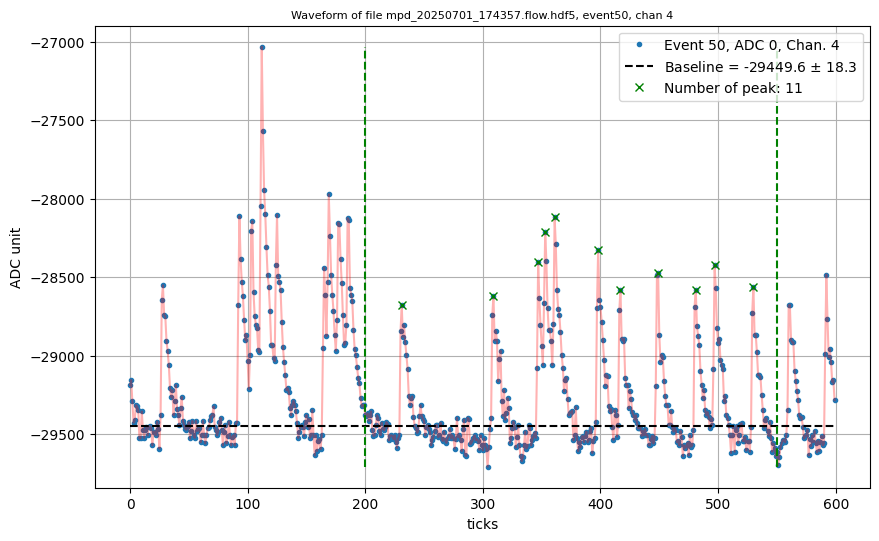

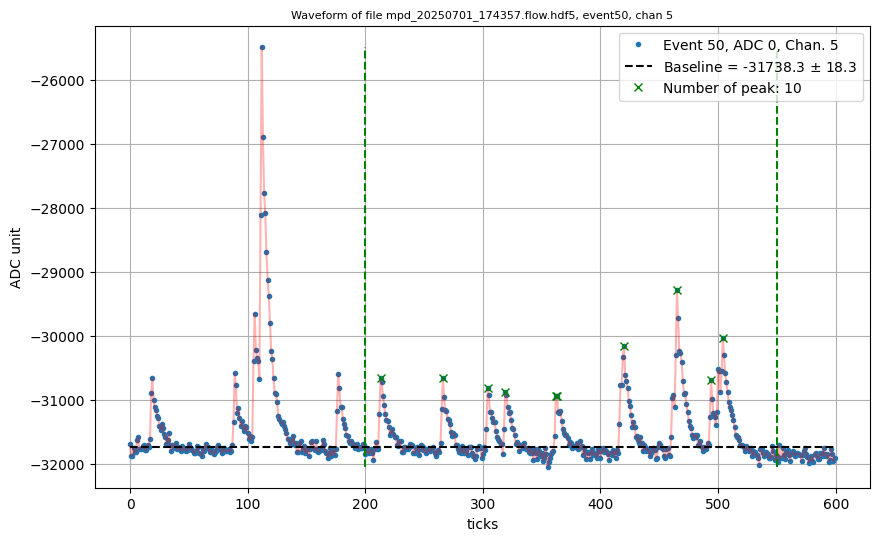

In [8]:
m_event = 50
i_adc = 0
k_chan = 0
j_file = 0

dc_window = [200, 550]

for k_chan in range(6):

    wvfm = calibClass.light_wvfms[m_event, i_adc, k_chan]
    baseline = files.baselines[j_file, i_adc, k_chan]

    calibClass.findPeak_wvfms(m_event, i_adc, k_chan, minWidth=9, search_int=dc_window)
    peaks_idx = calibClass.peaks_idx[m_event][i_adc][k_chan]
    print(peaks_idx)

    fig = plt.figure(figsize=[10, 6])
    ax = fig.subplots()

    # Compute the x-axis coordinate
    x_ticks = np.arange(0, wvfm.shape[-1],  1)

    xlim = [x_ticks[0], x_ticks[-1]]
    ylim = [np.min(wvfm), np.max(wvfm)]

    ax.set_xlabel('ticks')
    ax.set_ylabel('ADC unit')
    ax.grid(True)

    ax.plot(x_ticks, wvfm, label=f'Event {m_event}, ADC {i_adc}, Chan. {k_chan}', marker='.', ls='')
    ax.plot(x_ticks, wvfm, marker='', ls='-', c='r', alpha=0.3)

    ax.hlines(baseline, xlim[0], xlim[1], color='k', ls='--', label=rf'Baseline = {baseline:.1f} $\pm$ {baseline_std:.1f}')
    ax.vlines(dc_window[0], ylim[0], ylim[1], color='g', ls='--')
    ax.vlines(dc_window[1], ylim[0], ylim[1], color='g', ls='--')

    ax.plot(peaks_idx, wvfm[peaks_idx], color='g', marker='x', ls='', label=f'Number of peak: {len(peaks_idx)}')

    ax.set_title(f'Waveform of file {input_LEDFile}, event{m_event}, chan {k_chan}', fontsize=8)
    ax.legend()

    fig.show()


### Waveforms examples - Amplitude DC with 15ticks cut


[245 323 354]
[260 350 437 458 475]
[321 348 369 414 430 457 492]
[260 287 491]
[309 398 417 449 481 497]
[266 420 465]


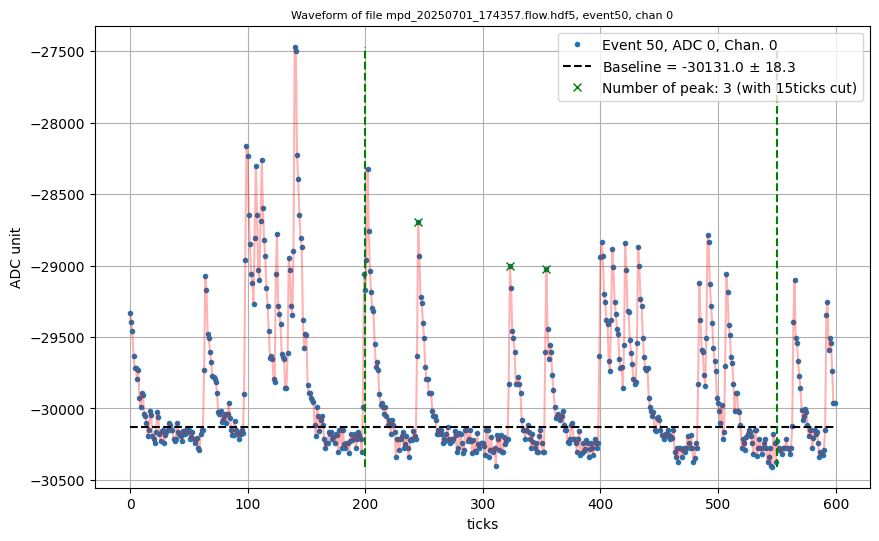

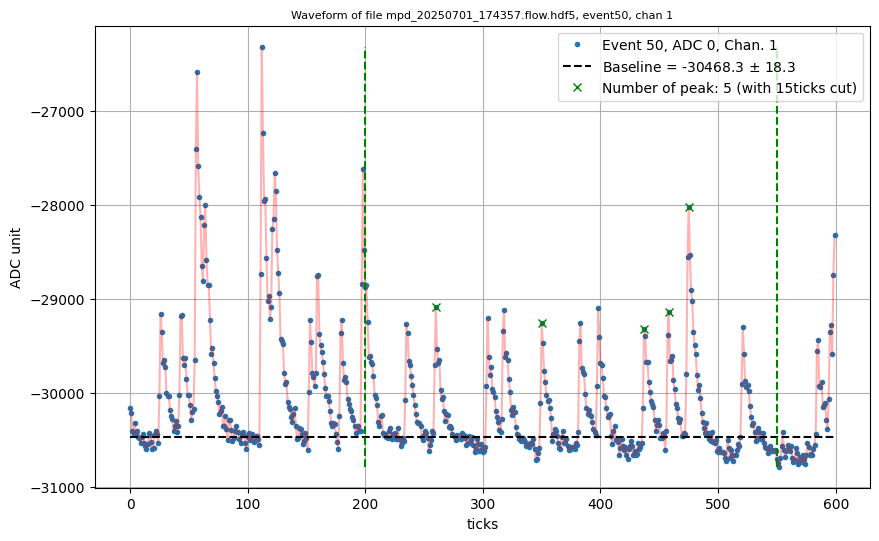

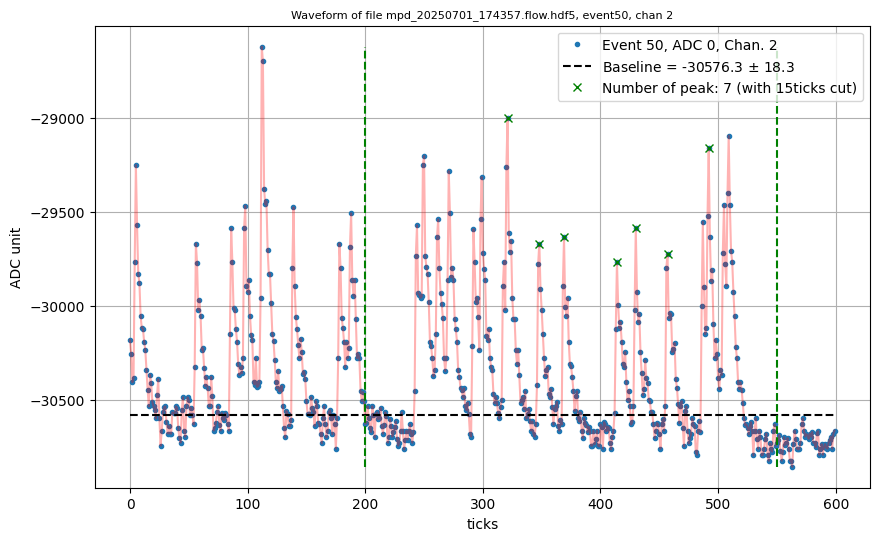

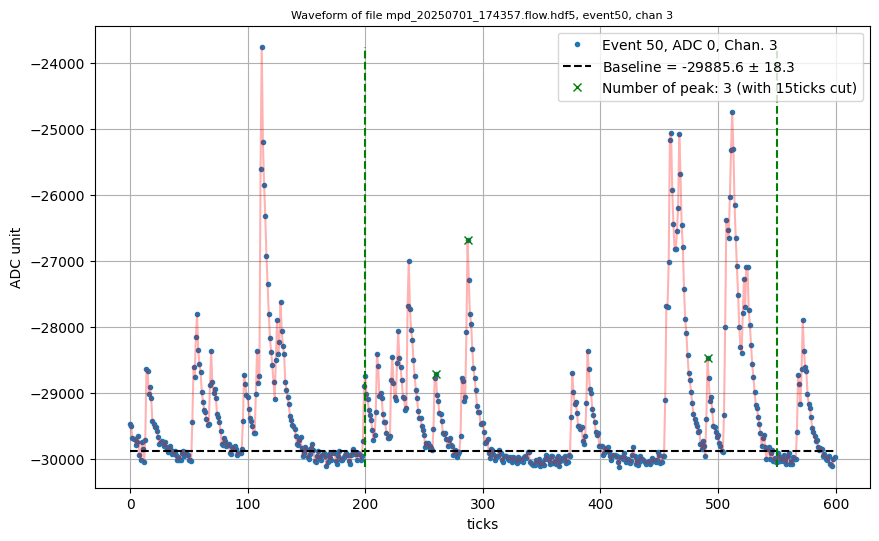

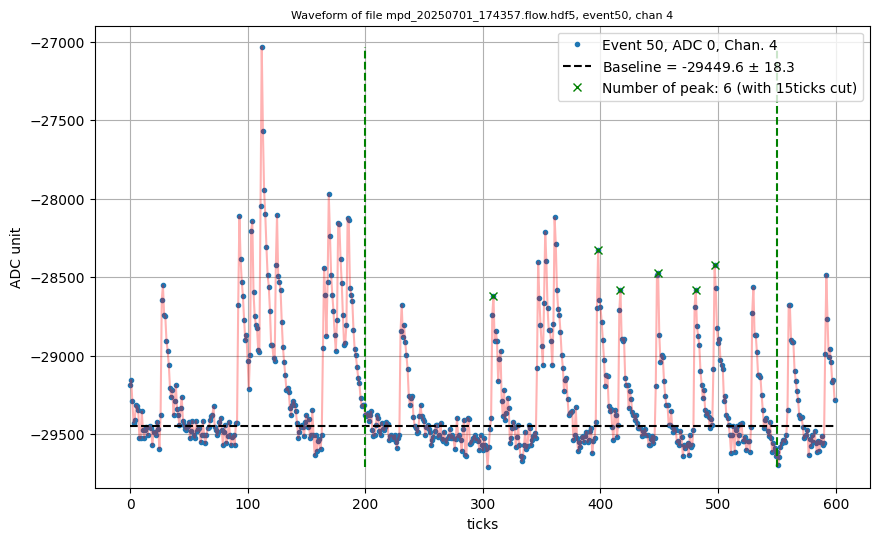

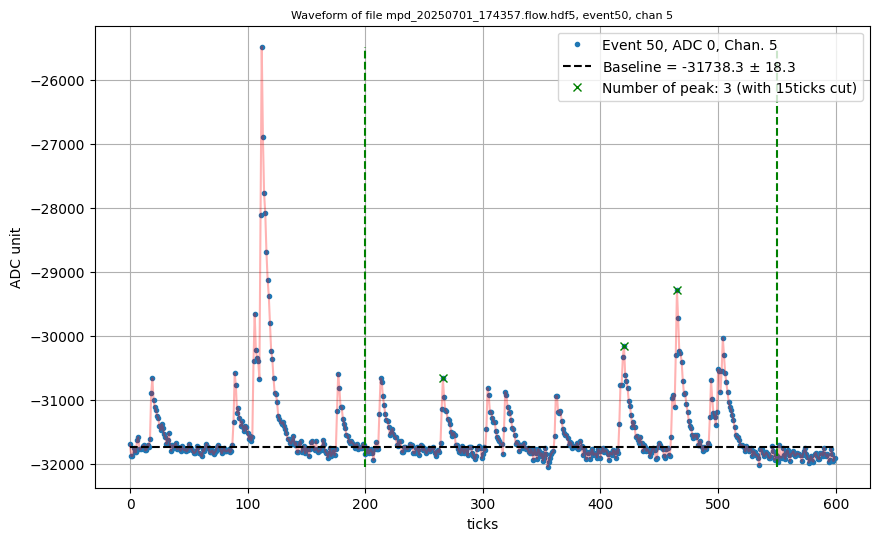

In [9]:
m_event = 50
i_adc = 0
k_chan = 0
j_file = 0

dc_window = [200, 550]

for k_chan in range(6):

    wvfm = calibClass.light_wvfms[m_event, i_adc, k_chan]
    baseline = files.baselines[j_file, i_adc, k_chan]

    calibClass.findPeak_wvfms(m_event, i_adc, k_chan, minWidth=9, search_int=dc_window, cut='15ticks')
    peaks_idx = calibClass.peaks_idx[m_event][i_adc][k_chan]
    print(peaks_idx)

    fig = plt.figure(figsize=[10, 6])
    ax = fig.subplots()

    # Compute the x-axis coordinate
    x_ticks = np.arange(0, wvfm.shape[-1],  1)

    xlim = [x_ticks[0], x_ticks[-1]]
    ylim = [np.min(wvfm), np.max(wvfm)]

    ax.set_xlabel('ticks')
    ax.set_ylabel('ADC unit')
    ax.grid(True)

    ax.plot(x_ticks, wvfm, label=f'Event {m_event}, ADC {i_adc}, Chan. {k_chan}', marker='.', ls='')
    ax.plot(x_ticks, wvfm, marker='', ls='-', c='r', alpha=0.3)

    ax.hlines(baseline, xlim[0], xlim[1], color='k', ls='--', label=rf'Baseline = {baseline:.1f} $\pm$ {baseline_std:.1f}')
    ax.vlines(dc_window[0], ylim[0], ylim[1], color='g', ls='--')
    ax.vlines(dc_window[1], ylim[0], ylim[1], color='g', ls='--')
    ax.plot(peaks_idx, wvfm[peaks_idx], color='g', marker='x', ls='', label=f'Number of peak: {len(peaks_idx)} (with 15ticks cut)')

    ax.set_title(f'Waveform of file {input_LEDFile}, event{m_event}, chan {k_chan}', fontsize=8)
    ax.legend()

    fig.show()

### Fingerplots example - Integral

In [10]:
calibClass.compute_fingerplots(Nevent = 10000, Int_window=signal_window, Nbins=150, mode='integral')

2025-07-24 00:21:03,649 - DEBUG - compute_fingerplots - Computing the fingerplots of the file /storage/data/LRS/test_VGA/light_flow_scanner/20250630_VGA_test/LED/mpd_20250701_174357.flow.hdf5 with 10000 events
2025-07-24 00:21:03,727 - DEBUG - compute_fingerplots - Finger plot computed with 10000 events in mode "integral"


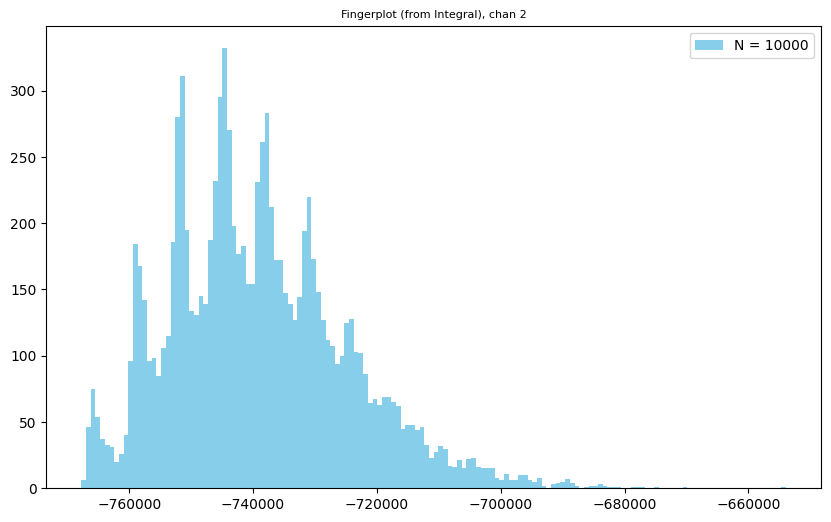

In [11]:
k_chan = 2

counts_int, bins_int = calibClass.fingerplots[0][k_chan]
title_int = f'Fingerplot (from Integral), chan {k_chan}'

plot_fingerplot(counts_int, bins_int, title_int)


### Fingerplots example - Integral with 1peak

In [12]:
calibClass.compute_fingerplots(Nevent = 10000, Int_window=signal_window, Nbins=100, mode='integral', cut='1peak')

2025-07-24 00:21:04,207 - DEBUG - compute_fingerplots - Computing the fingerplots of the file /storage/data/LRS/test_VGA/light_flow_scanner/20250630_VGA_test/LED/mpd_20250701_174357.flow.hdf5 with 10000 events


2025-07-24 00:21:49,954 - DEBUG - compute_fingerplots - Finger plot computed with 10000 events in mode "integral"


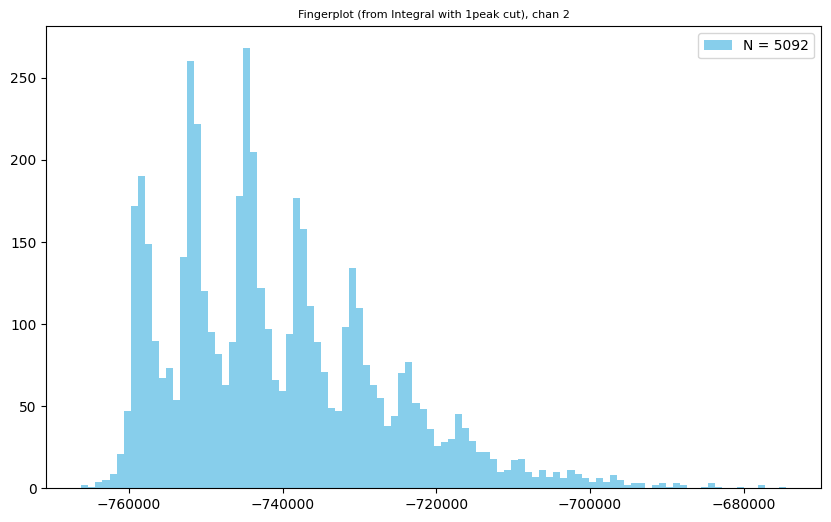

In [13]:
k_chan = 2

counts_int1peak, bins_int1peak = calibClass.fingerplots[0][k_chan]
title_int1peak = f'Fingerplot (from Integral with 1peak cut), chan {k_chan}'

plot_fingerplot(counts_int1peak, bins_int1peak, title_int1peak)

### Fingerplots example - Max. Amplitude

In [ ]:
calibClass.compute_fingerplots(Nevent = 10000, Int_window=signal_window, Nbins=150, mode='amplitude')

2025-07-24 00:21:50,401 - DEBUG - compute_fingerplots - Computing the fingerplots of the file /storage/data/LRS/test_VGA/light_flow_scanner/20250630_VGA_test/LED/mpd_20250701_174357.flow.hdf5 with 10000 events
2025-07-24 00:21:50,492 - DEBUG - compute_fingerplots - Finger plot computed with 10000 events in mode "amplitude"


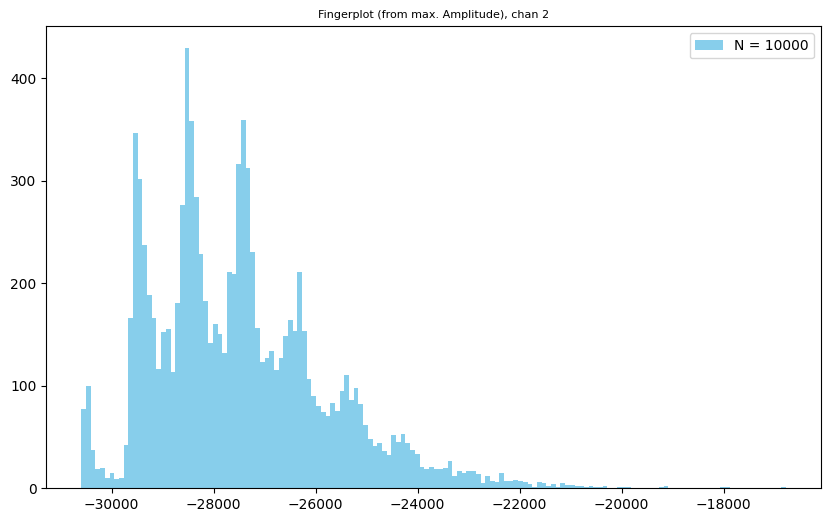

In [15]:
k_chan = 2

counts_amp, bins_amp = calibClass.fingerplots[0][k_chan]
title_amp = f'Fingerplot (from max. Amplitude), chan {k_chan}'

plot_fingerplot(counts_amp, bins_amp, title_amp)

### Fingerplots example - Amplitudes 

In [16]:
calibClass.compute_fingerplots(Nevent = 10000, Int_window=signal_window, Nbins=150, mode='amplitude_peak')

2025-07-24 00:21:51,073 - DEBUG - compute_fingerplots - Computing the fingerplots of the file /storage/data/LRS/test_VGA/light_flow_scanner/20250630_VGA_test/LED/mpd_20250701_174357.flow.hdf5 with 10000 events
2025-07-24 00:21:51,074 - DEBUG - compute_fingerplots - Finger plot computed with 10000 events in mode "amplitude_peak"


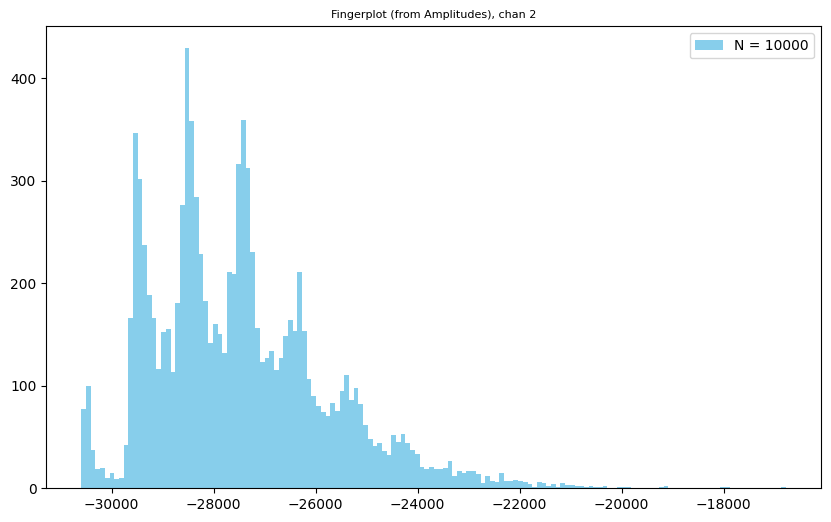

In [17]:
k_chan = 2

counts_amp1peak, bins_amp1peak = calibClass.fingerplots[0][k_chan]
title_amp1peak = f'Fingerplot (from Amplitudes), chan {k_chan}'

plot_fingerplot(counts_amp1peak, bins_amp1peak, title_amp1peak)

### Fingerplots example - Amplitudes from DC

In [18]:
calibClass.compute_fingerplots(Nevent = 10000, Int_window=dc_window, Nbins=150, mode='amplitude_peaks')

2025-07-24 00:21:51,515 - DEBUG - compute_fingerplots - Computing the fingerplots of the file /storage/data/LRS/test_VGA/light_flow_scanner/20250630_VGA_test/LED/mpd_20250701_174357.flow.hdf5 with 10000 events


2025-07-24 00:29:31,660 - DEBUG - compute_fingerplots - Finger plot computed with 10000 events in mode "amplitude_peaks"


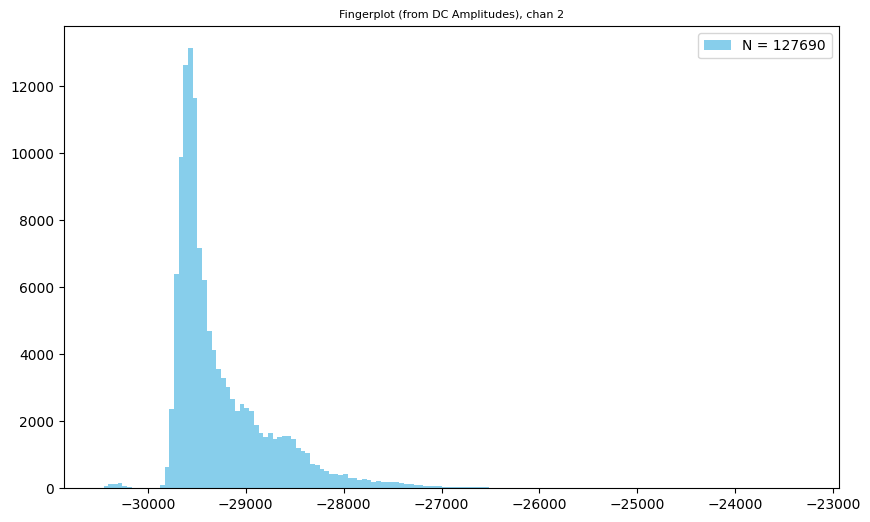

In [19]:
k_chan = 2

counts_ampDC, bins_ampDC = calibClass.fingerplots[0][k_chan]
title_ampDC = f'Fingerplot (from DC Amplitudes), chan {k_chan}'

plot_fingerplot(counts_ampDC, bins_ampDC, title_ampDC)

### Fingerplots example - Amplitudes from DC with 15 ticks cut

In [20]:
calibClass.compute_fingerplots(Nevent = 10000, Int_window=dc_window, Nbins=150, mode='amplitude_peaks', cut='15ticks')

2025-07-24 00:29:32,625 - DEBUG - compute_fingerplots - Computing the fingerplots of the file /storage/data/LRS/test_VGA/light_flow_scanner/20250630_VGA_test/LED/mpd_20250701_174357.flow.hdf5 with 10000 events
2025-07-24 00:37:06,713 - DEBUG - compute_fingerplots - Finger plot computed with 10000 events in mode "amplitude_peaks"


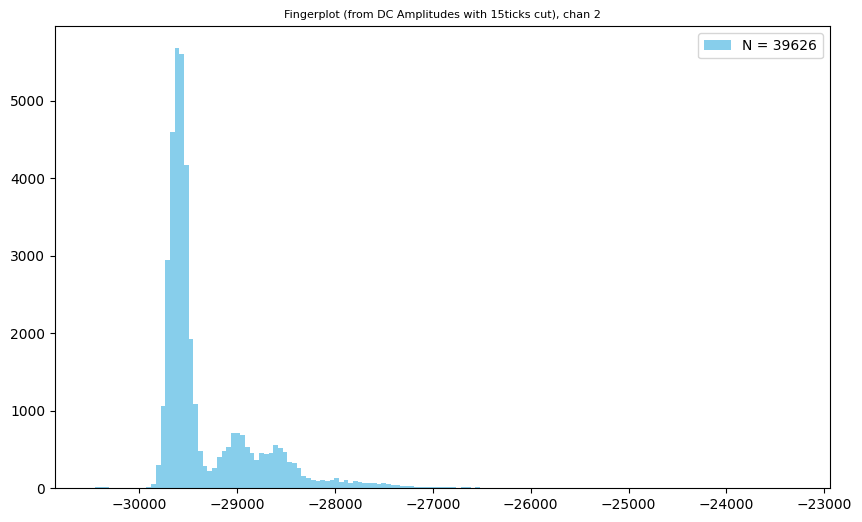

In [21]:
k_chan = 2

counts_ampDC_15ticks, bins_ampDC_15ticks = calibClass.fingerplots[0][k_chan]
title_ampDC_15ticks = f'Fingerplot (from DC Amplitudes with 15ticks cut), chan {k_chan}'

plot_fingerplot(counts_ampDC_15ticks, bins_ampDC_15ticks, title_ampDC_15ticks)

## Finger Plots - Fit

### Integral with 1peak cut

In [22]:
calibClass.compute_fingerplots(Nevent = 10000, Int_window=signal_window, Nbins=130, mode='integral', cut='1peak')


2025-07-24 00:37:07,679 - DEBUG - compute_fingerplots - Computing the fingerplots of the file /storage/data/LRS/test_VGA/light_flow_scanner/20250630_VGA_test/LED/mpd_20250701_174357.flow.hdf5 with 10000 events


2025-07-24 00:37:51,267 - DEBUG - compute_fingerplots - Finger plot computed with 10000 events in mode "integral"


In [86]:
k_chan = 5

counts_int1peak, bins_int1peak = calibClass.fingerplots[0][k_chan]
title_int1peak = f'Fingerplot (from Integral with 1peak cut), chan {k_chan}'

bin_centers_int1peak = (bins_int1peak[:-1] + bins_int1peak[1:]) / 2
width_int1peak = bins_int1peak[1] - bins_int1peak[0]



In [87]:
from scipy.signal import find_peaks

# find peaks

peaks_int1peak, properties = find_peaks(counts_int1peak, distance=5, width=1)



print(peaks_int1peak)
print(bin_centers_int1peak[0]+properties['left_ips']*width_int1peak)

[ 11  22  32  42  52  64  74  83  93 101 106 111 120 126]
[-787928.03869464 -780640.65730416 -773273.87127159 -765980.49276018
 -758818.59547511 -751194.52820513 -743514.86153846 -737063.94153846
 -729632.38717949 -723665.87692308 -720298.63846154 -716931.4
 -710196.92307692 -705943.56923077]


In [88]:
def NpeaksAboveThreshold(peaks_height, threshold):
    mask = peaks_height > threshold
    id_start = np.argmax(mask)
    id_end = np.argmax(~mask[id_start:])

#     print(f'mask = {mask},\
#           \nid_start: {id_start},\
#           \nid_end: {id_end},\
#           \n{mask[id_start:]},\n{~mask[id_start:]}')
    return id_end

    NpeaksAboveThreshold
    return NpeaksAboveThreshold

In [89]:
fingersplot_mean = np.mean(counts_int1peak)

NfingerAboveMean = NpeaksAboveThreshold(counts_int1peak[peaks_int1peak], fingersplot_mean)

# NfingerAboveMean = np.sum(counts_int1peak[peaks_int1peak] > fingersplot_mean)

fit_lim = np.array([properties['left_ips'][0]-2, int((peaks_int1peak[NfingerAboveMean-1]+peaks_int1peak[NfingerAboveMean])*0.5+2)], dtype=int)

x_fit = np.linspace(bin_centers_int1peak[fit_lim[0]], bin_centers_int1peak[fit_lim[1]], 1000)

# print(bin_centers_int1peak[fit_lim])

# print(NfingerAboveMean)

In [90]:
posRatio_noisePeak = 0.4

noise_peaks = np.array((peaks_int1peak[1:]-peaks_int1peak[:-1])*posRatio_noisePeak, dtype=int) + peaks_int1peak[:-1]

print(noise_peaks)

[ 15  26  36  46  56  68  77  87  96 103 108 114 122]


In [91]:
def multi_gaussian(x, *params):
    """
    Compute the sum of multiple Gaussians.
    Each Gaussian has 3 parameters: amplitude, mean, std_dev.
    
    Parameters:
        x: input array
        *params: variable length parameters [A1, mu1, sigma1, A2, mu2, sigma2, ..., An, mun, sigman]
        
    Returns:
        y: sum of Gaussians evaluated at x
    """
    y = np.zeros_like(x, dtype=float)
    num_gaussians = len(params) // 3
    
    for i in range(num_gaussians):
        A = params[3*i]
        mu = params[3*i + 1]
        sigma = params[3*i + 2]

        y += A * np.exp(-((x - mu)**2) / (2 * sigma**2))
        
    return y

In [92]:
Npeaks_fit = NfingerAboveMean

# 2 gaussian per peak and 3 params per gaussian
Nparams_peak = 6
fit_p0s = np.zeros(Npeaks_fit*Nparams_peak)
fit_bounds = np.zeros((2,Npeaks_fit*Nparams_peak))

for i_peak in range(Npeaks_fit):
    # Amplitue main gaussian
    fit_p0s[i_peak*Nparams_peak] = counts_int1peak[peaks_int1peak[i_peak]]
    fit_bounds[0][i_peak*Nparams_peak] = fit_p0s[i_peak*Nparams_peak]*0.95
    fit_bounds[1][i_peak*Nparams_peak] = fit_p0s[i_peak*Nparams_peak]*1.1
    # Mean main gaussian
    fit_p0s[i_peak*Nparams_peak+1] = bin_centers_int1peak[0]+width_int1peak*peaks_int1peak[i_peak]
    fit_bounds[0][i_peak*Nparams_peak+1] = fit_p0s[i_peak*Nparams_peak+1]-width_int1peak
    fit_bounds[1][i_peak*Nparams_peak+1] = fit_p0s[i_peak*Nparams_peak+1]+width_int1peak
    # Std main gaussian
    fit_p0s[i_peak*Nparams_peak+2] = properties['widths'][i_peak]*width_int1peak*0.5
    fit_bounds[0][i_peak*Nparams_peak+2] = fit_p0s[i_peak*Nparams_peak+2]*0.8
    fit_bounds[1][i_peak*Nparams_peak+2] = fit_p0s[i_peak*Nparams_peak+2]*2
    # Amplitue secondary gaussian
    fit_p0s[i_peak*Nparams_peak+3] = counts_int1peak[noise_peaks[i_peak]]
    fit_bounds[0][i_peak*Nparams_peak+3] = fit_p0s[i_peak*Nparams_peak+3]*0.6
    fit_bounds[1][i_peak*Nparams_peak+3] = fit_p0s[i_peak*Nparams_peak+3]*1.1
    # Mean secondary gaussian
    fit_p0s[i_peak*Nparams_peak+4] = bin_centers_int1peak[0]+width_int1peak*noise_peaks[i_peak]
    fit_bounds[0][i_peak*Nparams_peak+4] = fit_p0s[i_peak*Nparams_peak+4]-width_int1peak
    fit_bounds[1][i_peak*Nparams_peak+4] = fit_p0s[i_peak*Nparams_peak+4]+2*width_int1peak
    # Amplitue secondary gaussian
    # Std secondary gaussian
    fit_p0s[i_peak*Nparams_peak+5] = (properties['widths'][i_peak]*width_int1peak*0.5)
    fit_bounds[0][i_peak*Nparams_peak+5] = fit_p0s[i_peak*Nparams_peak+5]*0.8
    fit_bounds[1][i_peak*Nparams_peak+5] = fit_p0s[i_peak*Nparams_peak+5]*5






In [93]:

# finger_p0 = multi_gaussian(x_fit, counts_int1peak[peaks_int1peak[0]], bin_centers_int1peak[0]+width_int1peak*peaks_int1peak[0], properties['widths'][0]*width_int1peak*0.5, counts_int1peak[peaks_int1peak[1]], bin_centers_int1peak[0]+width_int1peak*peaks_int1peak[1], properties['widths'][1]*width_int1peak*0.5, counts_int1peak[peaks_int1peak[2]], bin_centers_int1peak[0]+width_int1peak*peaks_int1peak[2], properties['widths'][2]*width_int1peak*0.5, counts_int1peak[peaks_int1peak[3]], bin_centers_int1peak[0]+width_int1peak*peaks_int1peak[3], properties['widths'][3]*width_int1peak*0.5, counts_int1peak[peaks_int1peak[4]], bin_centers_int1peak[0]+width_int1peak*peaks_int1peak[4], properties['widths'][4]*width_int1peak*0.5)
fingersplot_p0 = multi_gaussian(x_fit, *fit_p0s)



params: [ 2.37000000e+02 -7.87111738e+05  9.93756806e+02]
params: [ 6.70000000e+01 -7.84276169e+05  9.93756806e+02]
params: [ 2.79000000e+02 -7.79313923e+05  1.26592558e+03]
params: [ 8.20000000e+01 -7.76478354e+05  1.26592558e+03]
params: [ 2.5000000e+02 -7.7222500e+05  1.1269941e+03]
params: [ 7.30000000e+01 -7.69389431e+05  1.12699410e+03]
params: [ 1.60000000e+02 -7.65136077e+05  1.35002285e+03]
params: [ 6.00000000e+01 -7.62300508e+05  1.35002285e+03]
params: [ 8.70000000e+01 -7.58047154e+05  1.54121528e+03]
params: [ 4.40000000e+01 -7.55211585e+05  1.54121528e+03]
params: [ 5.50000000e+01 -7.49540446e+05  1.28782103e+03]
params: [ 1.80000000e+01 -7.46704877e+05  1.28782103e+03]


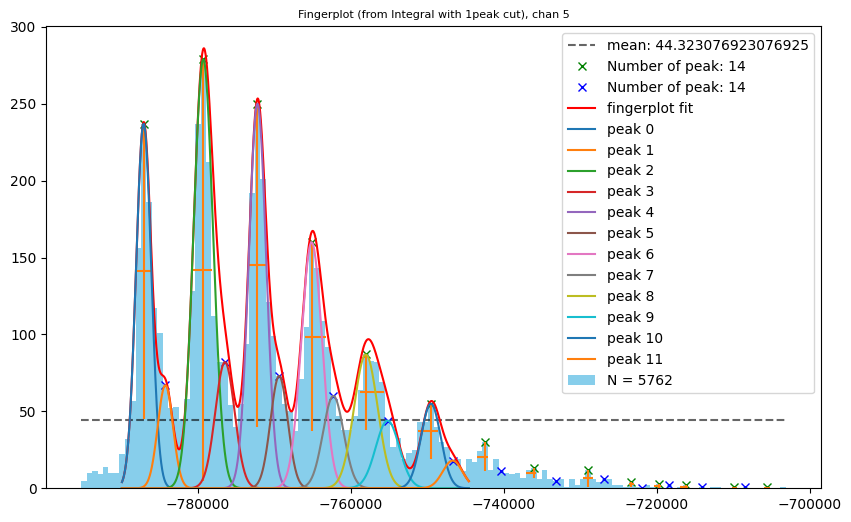

In [94]:
fig = plt.figure(figsize=[10, 6])
ax = fig.subplots()

# baseline_params = [45, -736012, 12798]

ax.bar(bin_centers_int1peak, counts_int1peak, width=width_int1peak, color='skyblue', label=f'N = {np.sum(counts_int1peak)}')
ax.hlines(fingersplot_mean, bins_int1peak[0], bins_int1peak[-1], color='k', ls='--', alpha=0.6, label=f'mean: {fingersplot_mean}')
ax.plot(bin_centers_int1peak[peaks_int1peak], counts_int1peak[peaks_int1peak], color='g', marker='x', ls='', label=f'Number of peak: {len(peaks_int1peak)}')

ax.plot(bin_centers_int1peak[noise_peaks], counts_int1peak[noise_peaks], color='b', marker='x', ls='', label=f'Number of peak: {len(peaks_int1peak)}')

ax.hlines(y=properties["width_heights"], xmin=bin_centers_int1peak[0]+properties['left_ips']*width_int1peak, xmax=bin_centers_int1peak[0]+properties['right_ips']*width_int1peak, color = "C1")
ax.vlines(x=bin_centers_int1peak[peaks_int1peak], ymin=counts_int1peak[peaks_int1peak] - properties["prominences"],
           ymax = counts_int1peak[peaks_int1peak], color = "C1")


ax.plot(x_fit, fingersplot_p0, color='r', ls='-', label='fingerplot fit')


for j_peak in range(Npeaks_fit*2):
    print(f'params: {fit_p0s[j_peak*int(Nparams_peak*0.5):(j_peak+1)*int(Nparams_peak*0.5)]}')
    ax.plot(x_fit , multi_gaussian(x_fit, *fit_p0s[j_peak*int(Nparams_peak*0.5):(j_peak+1)*int(Nparams_peak*0.5)]), label=f'peak {j_peak}')
# ax.plot(x_fit , multi_gaussian(x_fit, *baseline_params), color='magenta')


ax.set_title(title_int1peak, fontsize=8)
ax.legend()

fig.show()

### Curve_fit

In [95]:
from scipy.optimize import curve_fit

In [96]:
popt, pcov = curve_fit(multi_gaussian, bin_centers_int1peak[fit_lim[0]:fit_lim[1]], counts_int1peak[fit_lim[0]:fit_lim[1]], p0=fit_p0s, bounds=fit_bounds, maxfev = 100000)

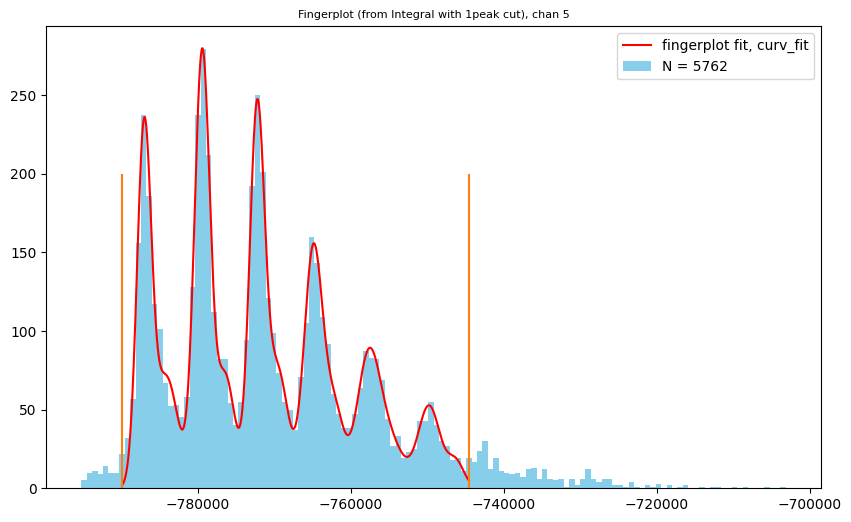

In [97]:
fig = plt.figure(figsize=[10, 6])
ax = fig.subplots()

ax.bar(bin_centers_int1peak, counts_int1peak, width=width_int1peak, color='skyblue', label=f'N = {np.sum(counts_int1peak)}')
# ax.hlines(fingersplot_mean, bins_int1peak[0], bins_int1peak[-1], color='k', ls='--', alpha=0.6, label=f'mean: {fingersplot_mean}')
# ax.plot(bin_centers_int1peak[peaks_int1peak], counts_int1peak[peaks_int1peak], color='g', marker='x', ls='', label=f'Number of peak: {len(peaks_int1peak)}')

# ax.plot(bin_centers_int1peak[noise_peaks], counts_int1peak[noise_peaks], color='b', marker='x', ls='', label=f'Number of peak: {len(peaks_int1peak)}')

# ax.hlines(y=properties["width_heights"], xmin=bin_centers_int1peak[0]+properties['left_ips']*width_int1peak, xmax=bin_centers_int1peak[0]+properties['right_ips']*width_int1peak, color = "C1")
# ax.vlines(x=bin_centers_int1peak[peaks_int1peak], ymin=counts_int1peak[peaks_int1peak] - properties["prominences"],
#            ymax = counts_int1peak[peaks_int1peak], color = "C1")


ax.plot(x_fit, multi_gaussian(x_fit, *popt), color='r', ls='-', label='fingerplot fit, curv_fit')

ax.vlines(x=bin_centers_int1peak[fit_lim], ymin=0, ymax=200, color = "C1")

# for j_peak in range(Npeaks_fit*2):
#     print(f'params: {fit_p0s[j_peak*int(Nparams_peak*0.5):(j_peak+1)*int(Nparams_peak*0.5)]}')
#     ax.plot(x_fit , multi_gaussian(x_fit, *fit_p0s[j_peak*int(Nparams_peak*0.5):(j_peak+1)*int(Nparams_peak*0.5)]), label=f'peak {j_peak}')


ax.set_title(title_int1peak, fontsize=8)
ax.legend()

fig.show()